# Clima horario (Open-Meteo) — Visualizaciones + Dashboard mensual

Este notebook descarga (o reutiliza) datos horarios de **Open‑Meteo Archive**, construye un `DataFrame` limpio y genera un set de visualizaciones que dan **intuición rápida** de:
- Evolución a lo largo del tiempo
- Ciclos diarios típicos por mes (0–23)
- Evolución típica dentro del mes (día 1–31) con banda
- Un **dashboard 4×3** (12 meses) para una variable (por defecto: **temperatura**)

> Nota sobre variables:
> - `temperature_2m`, `relative_humidity_2m`: medidas/estimadas a **2 m sobre el suelo** (estándar meteorológico).
> - `wind_speed_10m`: a **10 m** (estándar).
> - `pressure_msl`: presión reducida a **nivel del mar** para comparación regional.


## 1) Configuración — ubicación, fechas y variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Para suavizado visual (splines)
from scipy.interpolate import CubicSpline

# -----------------------------
# Parámetros editables
# -----------------------------
# Coordenadas Catec
LAT = 20.535013503912094
LON = -100.21144639229682

# Rango (formato ISO YYYY-MM-DD)
START_DATE = "2025-01-01"
END_DATE   = "2025-09-02"   # ajusta si necesitas otro rango

# Variables a descargar (Open-Meteo)
HOURLY_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "precipitation",
    "wind_speed_10m"
]

# Archivo local (cache)
CSV_PATH = "clima_horario_openmeteo.csv"


## 2) Descargar datos (o reutilizar CSV si ya existe)

In [2]:
import os, requests

def FetchOpenMeteoArchiveHourly(lat, lon, start_date, end_date, hourly_vars, timezone="auto"):
    """Descarga histórico horario desde Open‑Meteo Archive API."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(hourly_vars),
        "timezone": timezone
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    return r.json()

if os.path.exists(CSV_PATH):
    print(f"Usando CSV existente: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)
else:
    print("Descargando datos desde Open‑Meteo...")
    data = FetchOpenMeteoArchiveHourly(LAT, LON, START_DATE, END_DATE, HOURLY_VARS, timezone="auto")
    df = pd.DataFrame(data["hourly"])
    df.to_csv(CSV_PATH, index=False)
    print(f"CSV guardado: {CSV_PATH}")

df.head()


Descargando datos desde Open‑Meteo...
CSV guardado: clima_horario_openmeteo.csv


,time,temperature_2m,relative_humidity_2m,pressure_msl,precipitation,wind_speed_10m
0,2025-01-01T00:00,11.6,47,1019.2,0.0,8.5
1,2025-01-01T01:00,10.6,52,1019.5,0.0,8.9
2,2025-01-01T02:00,9.6,54,1019.7,0.0,9.1
3,2025-01-01T03:00,8.9,54,1019.8,0.0,9.2
4,2025-01-01T04:00,8.2,56,1019.9,0.0,8.3


## 3) Preparación del DataFrame

In [3]:
# Parsear tiempo
df["time"] = pd.to_datetime(df["time"])

# Features temporales útiles
df["month"] = df["time"].dt.to_period("M")   # 2025-01, 2025-02...
df["date"]  = df["time"].dt.date             # fecha (YYYY-MM-DD)
df["day"]   = df["time"].dt.day              # 1..31
df["hour"]  = df["time"].dt.hour             # 0..23

# Reordenar columnas para lectura
cols = ["time", "month", "date", "day", "hour"] + [c for c in df.columns if c not in ["time","month","date","day","hour"]]
df = df[cols]

print(df.dtypes)
df.head()


time                    datetime64[us]
month                        period[M]
date                            object
day                              int32
hour                             int32
temperature_2m                 float64
relative_humidity_2m             int64
pressure_msl                   float64
precipitation                  float64
wind_speed_10m                 float64
dtype: object


,time,month,date,day,hour,temperature_2m,relative_humidity_2m,pressure_msl,precipitation,wind_speed_10m
0,2025-01-01 00:00:00,2025-01,2025-01-01,1,0,11.6,47,1019.2,0.0,8.5
1,2025-01-01 01:00:00,2025-01,2025-01-01,1,1,10.6,52,1019.5,0.0,8.9
2,2025-01-01 02:00:00,2025-01,2025-01-01,1,2,9.6,54,1019.7,0.0,9.1
3,2025-01-01 03:00:00,2025-01,2025-01-01,1,3,8.9,54,1019.8,0.0,9.2
4,2025-01-01 04:00:00,2025-01,2025-01-01,1,4,8.2,56,1019.9,0.0,8.3


## 7) Dashboard 4×3 (12 meses) — Promedio por día con banda
Este panel permite comparar rápidamente el **patrón mensual** en un solo vistazo.
Por defecto: `temperature_2m`. Puedes cambiar `DASH_COL`.

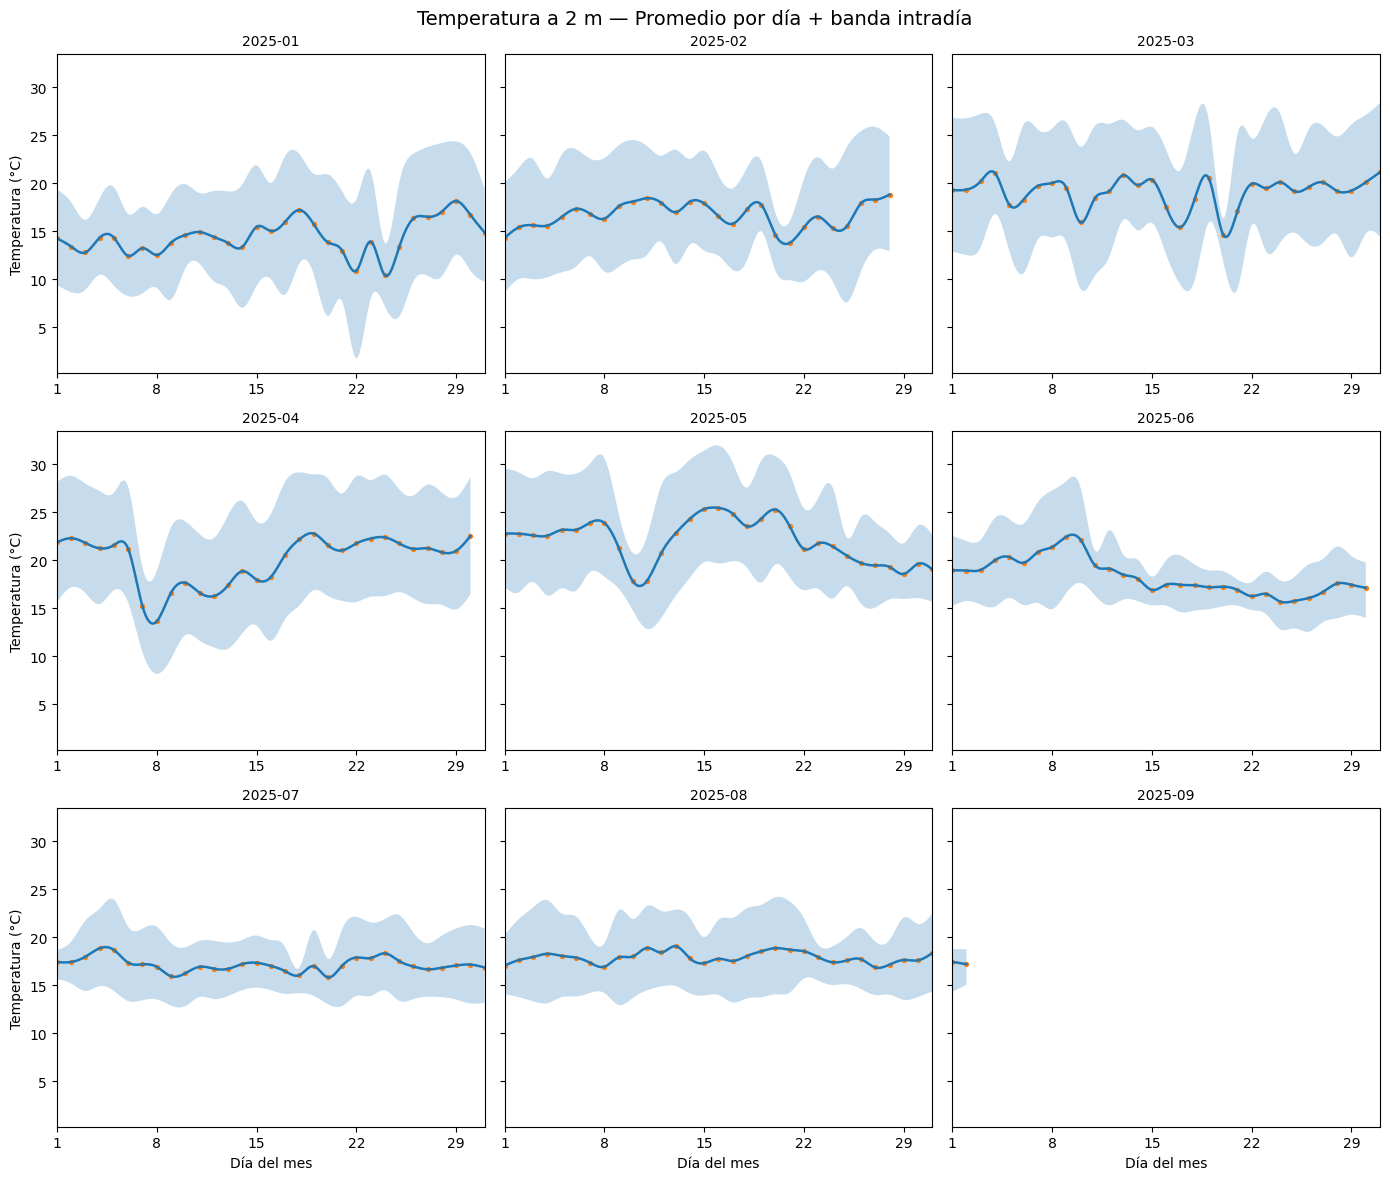

In [4]:
DASH_COL = "temperature_2m"
DASH_YLABEL = "Temperatura (°C)"
DASH_TITLE = "Temperatura a 2 m — Promedio por día + banda intradía"

# Si no hay 12 meses en el dataset, mostramos los disponibles
months = sorted(df["month"].unique())
n = len(months)

rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 12), sharey=True)
axes = axes.ravel()

for i in range(rows*cols):
    ax = axes[i]
    if i >= n:
        ax.axis("off")
        continue

    m = months[i]
    dm = df[df["month"] == m].copy()

    per_date = (
        dm.groupby(["day","date"])[DASH_COL]
          .agg(
              mean="mean",
              plo=lambda s: s.quantile(0.25),
              phi=lambda s: s.quantile(0.75),
          )
          .reset_index()
          .dropna()
    )

    g = per_date.groupby("day").agg(
        mean=("mean","mean"),
        plo=("plo","mean"),
        phi=("phi","mean"),
    ).reset_index().sort_values("day")

    x = g["day"].to_numpy()
    y_mean = g["mean"].to_numpy()
    y_lo = g["plo"].to_numpy()
    y_hi = g["phi"].to_numpy()

    if len(x) >= 4:
        xs = np.linspace(x.min(), x.max(), 300)
        s_mean = CubicSpline(x, y_mean, bc_type="natural")
        s_lo   = CubicSpline(x, y_lo,   bc_type="natural")
        s_hi   = CubicSpline(x, y_hi,   bc_type="natural")

        yms = s_mean(xs)
        yls = s_lo(xs)
        yhs = s_hi(xs)

        yls2 = np.minimum(yls, yhs)
        yhs2 = np.maximum(yls, yhs)

        # FIX: precipitación no puede ser negativa
        if DASH_COL == "precipitation":
            yms  = np.clip(yms,  0, None)
            yls2 = np.clip(yls2, 0, None)
            yhs2 = np.clip(yhs2, 0, None)

        ax.plot(xs, yms, linewidth=1.8)
        ax.fill_between(xs, yls2, yhs2, alpha=0.25)
        ax.scatter(x, y_mean, s=8)
    else:
        if DASH_COL == "precipitation":
            y_mean = np.clip(y_mean, 0, None)
            y_lo   = np.clip(y_lo,   0, None)
            y_hi   = np.clip(y_hi,   0, None)

        ax.plot(x, y_mean, linewidth=1.8)
        ax.fill_between(x, y_lo, y_hi, alpha=0.25)
        ax.scatter(x, y_mean, s=8)

    ax.set_title(str(m), fontsize=10)
    ax.set_xlim(1, 31)
    ax.set_xticks([1, 8, 15, 22, 29])

for r in range(rows):
    axes[r*cols].set_ylabel(DASH_YLABEL)

for c in range(cols):
    axes[(rows-1)*cols + c].set_xlabel("Día del mes")

fig.suptitle(DASH_TITLE, fontsize=14)
plt.tight_layout()
plt.show()


## 8) Tips de lectura
- Banda estrecha: días más estables.
- Banda ancha: variabilidad intradía (frentes, nubes, viento, etc.).
- Cambios de nivel entre meses: estacionalidad.
- Para precipitación: suele convenir sumar por día y comparar eventos (picos).

In [5]:
cols_export = [
    "time",
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "precipitation",
    "wind_speed_10m",
]

df[cols_export].to_parquet(
    "../data/interim/clima.parquet",
    index=False
)